# Curvas de aprendizaje

Daniela Gonzalez Molina

## ¿Como enfrentar el problema del sesgo alto? (High bias)

Incrementar la complejidad del modelo
- Tecnicas de regularización
- Modificar la partidicon de los datos del conjunto inicial
- Preprocesamiento
- Agregar factores que ayuden a explicar la variable de salida

## ¿Cómo enfrentar el problema del varianza alta? (High variance)

-Preprocesamiento 
-Regularizar 
-Mayor cantidad de epocas 
-Agregar más datos 
-Simplificar el modelo
-Batch(lotes) / early stopping 

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold

In [14]:
# leyendo y cargando los datos:

mypath = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/australian/australian.dat"
data = pd.read_csv(mypath, sep=" ", header=None)
data.columns = ['A1','A2','A3','A4','A5','A6','A7','A8','A9','A10','A11','A12','A13','A14','class']

# Algunos ajustes previos con datos categóricos con niveles de muy baja frecuencia con fines didácticos:
data['A4'] = data['A4'].map({2:2, 1:0, 3:0})
data['A5'] = data['A5'].map({1:1,2:0,3:3,4:4,5:0,6:6,7:7,8:8,9:9,10:0,11:11,12:0,13:13,14:14})
data['A6'] = data['A6'].map({1:1,2:0,3:0,4:4,5:5,7:0,8:8,9:0})

# Definimos nuestros datos de entrada, de salida y la partición correspondiente:
X = data.iloc[:,:-1]  
Y = data.iloc[:,-1]      

Xtv, Xtest, ytv, ytest = train_test_split(X, Y, test_size=0.2, random_state=1)  
print(Xtv.shape, ': dimensión de datos de entrada de entrenamiento y validación')
print(Xtest.shape, ': dimensión de datos de entrada de prueba')  
print(ytv.shape, ': dimensión de variable de salida para entrenamiento y validación')
print(ytest.shape, ': dimensión de variable de salida para prueba')

(552, 14) : dimensión de datos de entrada de entrenamiento y validación
(138, 14) : dimensión de datos de entrada de prueba
(552,) : dimensión de variable de salida para entrenamiento y validación
(138,) : dimensión de variable de salida para prueba


In [15]:
# Transformaciones a factores numéricos de entrada:
num_pipeline = Pipeline(steps = [('impMediana', SimpleImputer(strategy='median')),
                                 ('escalaNum', MinMaxScaler(feature_range=(1,2)))])   
num_pipeline_nombres = ['A2','A3','A7','A10','A13','A14']

# Transformaciones a factores categóricos de entrada:
catImp_pipeline = Pipeline(steps = [('impModa', SimpleImputer(strategy='most_frequent'))])  
catImp_pipeline_nombres = ['A1', 'A4', 'A5', 'A6', 'A8', 'A9', 'A11', 'A12']

# Transformaciones one-hot-encoder en algunas de las categóricas:
catOHE_pipeline = Pipeline(steps = [('OneHotE', OneHotEncoder(drop='first'))])
catOHE_pipeline_nombres = [ 'A4','A5','A6','A12']

# Conjuntamos las transformaciones numéricas y categóricas que se estarán aplicando a los datos de entrada:
columnasTransformer = ColumnTransformer(transformers = [('numpipe', num_pipeline, num_pipeline_nombres),
                                                        ('catimp', catImp_pipeline, catImp_pipeline_nombres),
                                                        ('catohe', catOHE_pipeline, catOHE_pipeline_nombres)],
                                        remainder='passthrough')

In [16]:
from sklearn.model_selection import validation_curve

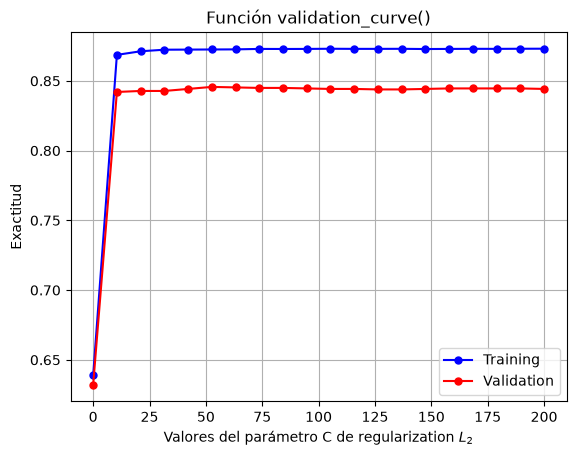

In [17]:
delta_C = np.linspace(.0001, 200., 20)

modelo = LogisticRegression(penalty='l2', 
                            max_iter=10000,
                            solver='liblinear',
                            random_state=1)

Xx = columnasTransformer.fit_transform(Xtv)

cvLC = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=11)

train_scores, valid_scores = validation_curve(modelo, 
                                              Xx, 
                                              np.ravel(ytv), 
                                              param_name="C", 
                                              param_range=delta_C,
                                              cv=cvLC,
                                              scoring='accuracy')


train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
valid_mean = np.mean(valid_scores, axis=1)
valid_std = np.std(valid_scores, axis=1)


# Curva de entrenamiento con la métrica de exactitud (accuracy):
plt.plot(delta_C, train_mean, color='blue', marker='o', markersize=5, label='Training')

# Curva de validación:
plt.plot(delta_C, valid_mean, color='red', marker='o', markersize=5, label='Validation')



plt.title('Función validation_curve()')
plt.xlabel('Valores del parámetro C de regularization $L_2$')
plt.ylabel('Exactitud')
plt.grid()
plt.legend(loc='lower right')
plt.show()

In [18]:
# Salvo el primer valor, el modelo se mantiene casi constante tanto para
# los datos de entrenamiento como de validación:

print('Valor promedio de los resultados con los conjuntos de entrenamiento: %.3f' % train_mean[1:20].mean())
print('Valor promedio de los resultados con los conjuntos de validación: %.3f' % valid_mean[1:20].mean())

Valor promedio de los resultados con los conjuntos de entrenamiento: 0.873
Valor promedio de los resultados con los conjuntos de validación: 0.844


# Curva de aprendizaje con base al tamaño del conjunto de entrenamiento 

In [19]:
modeloLC = LogisticRegression(penalty='12',
max_iter=10000,
C=100.,
solver='liblinear',
random_state=1)

In [20]:
from sklearn.model_selection import learning_curve

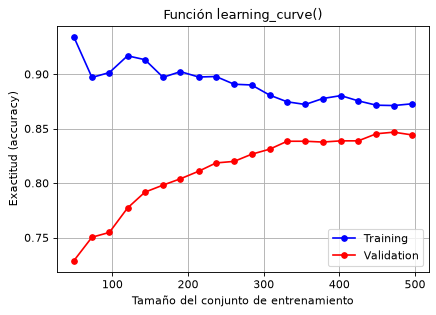

In [21]:
delta_train_sz = np.linspace(0.1, 1.0, 20)

cvLC = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=11)

modeloLC = LogisticRegression(penalty='l2',
                              max_iter=10000,
                              C=100.,
                              solver='liblinear',
                              random_state=1)



# Obtengamos la gráfica de las curvas de aprendizaje 
# cuando se incrementa el tamaño de la muestra:

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
valid_mean = np.mean(valid_scores, axis=1)
valid_std = np.std(valid_scores, axis=1)

train_sizes, train_scores, valid_scores = learning_curve(modeloLC,
                                                          Xx,
                                                          np.ravel(ytv),
                                                          train_sizes=delta_train_sz,
                                                          cv=cvLC,
                                                          scoring='accuracy')

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
valid_mean = np.mean(valid_scores, axis=1)
valid_std = np.std(valid_scores, axis=1)

plt.figure(figsize=(6,4), dpi=80)

plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, label='Training')

plt.plot(train_sizes, valid_mean, color='red', marker='o', markersize=5, label='Validation')

plt.title('Función learning_curve()')
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('Exactitud (accuracy)')
plt.grid()
plt.legend(loc='lower right')
plt.show()

